Dataset Loaded
         Date       Open   High        Low      Close  Adj Close    Volume
0  2010-06-29  19.000000  25.00  17.540001  23.889999  23.889999  18766300
1  2010-06-30  25.790001  30.42  23.299999  23.830000  23.830000  17187100
2  2010-07-01  25.000000  25.92  20.270000  21.959999  21.959999   8218800
3  2010-07-02  23.000000  23.10  18.709999  19.200001  19.200001   5139800
4  2010-07-06  20.000000  20.00  15.830000  16.110001  16.110001   6866900
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB
None


C:\Users\shara\AppData\Local\Temp\ipykernel_18168\2909916651.py:42: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


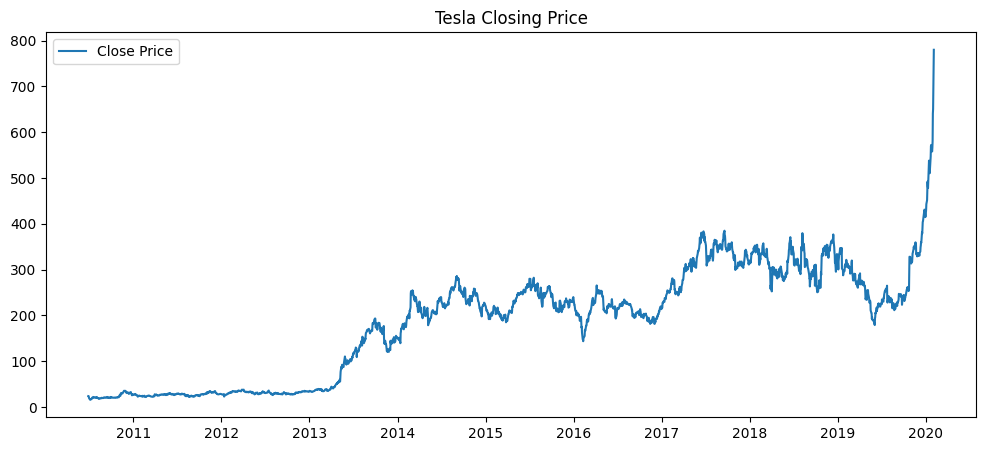

E:\TeslaStockPrediction\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training RNN...
Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - loss: 0.0654 - val_loss: 0.0072
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0113 - val_loss: 0.0022
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0060 - val_loss: 0.0015
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0043 - val_loss: 0.0017
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.0032 - val_loss: 0.0013
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 0.0025 - val_loss: 0.0011
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0024 - val_loss: 0.0010
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0022 - val_loss: 9.4326e-04
Epoch 9/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0018 - val_loss: 8.3560e-04
Epoch 10/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0015 - val_loss: 7.9244e-04
Epoch 11/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0015 - val_loss: 8.8574e-04
Epoch 12/20
59/59 ━━━━━━━━━━━━

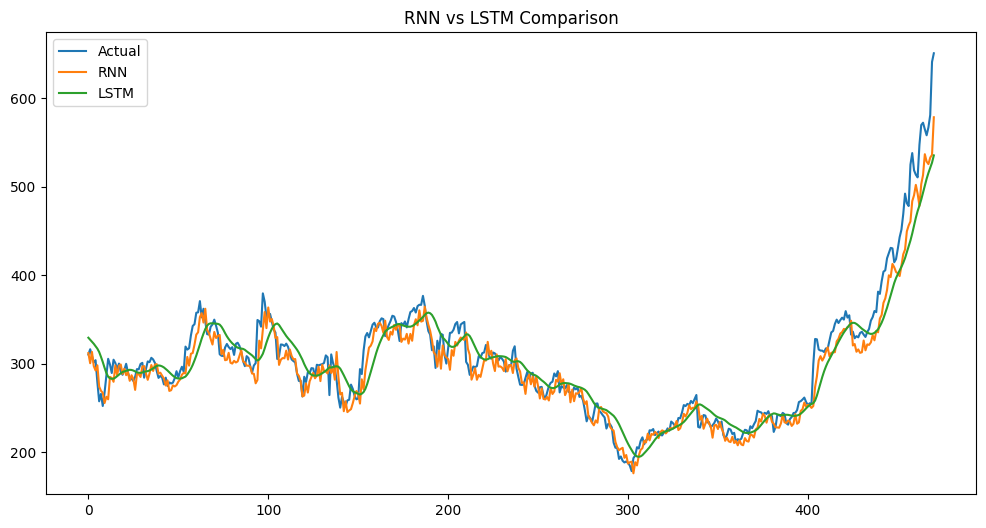

RNN MSE: 342.55320334154925
LSTM MSE: 618.8469578350183
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


Next Day Prediction: 561.54254
Models saved successfully!


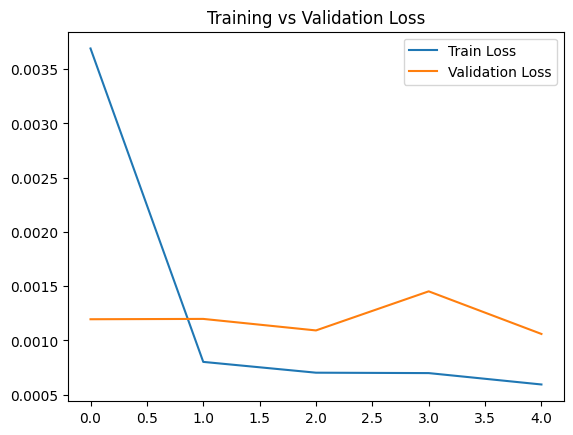

In [2]:
# ================================
# Tesla Stock Price Prediction
# ================================

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------------
# Load Dataset
# -------------------------------
df = pd.read_csv('../data/TSLA.csv')

print("Dataset Loaded")
print(df.head())

# -------------------------------
# Data Info
# -------------------------------
print(df.info())
print(df.describe())

# -------------------------------
# Missing Values
# -------------------------------
print(df.isnull().sum())

# -------------------------------
# Data Cleaning
# -------------------------------
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.fillna(method='ffill', inplace=True)

# -------------------------------
# Visualization
# -------------------------------
plt.figure(figsize=(12,5))
plt.plot(df['Close'], label='Close Price')
plt.title("Tesla Closing Price")
plt.legend()
plt.show()

# -------------------------------
# Feature Selection
# -------------------------------
data = df[['Close']]

# -------------------------------
# Scaling
# -------------------------------
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

# -------------------------------
# Create Dataset
# -------------------------------
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data)-time_step-1):
        X.append(data[i:(i+time_step), 0])
        y.append(data[i+time_step, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

# -------------------------------
# Reshape
# -------------------------------
X = X.reshape(X.shape[0], X.shape[1], 1)

# -------------------------------
# Train-Test Split
# -------------------------------
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# -------------------------------
# SimpleRNN Model
# -------------------------------
model_rnn = Sequential()
model_rnn.add(SimpleRNN(50, return_sequences=True, input_shape=(60,1)))
model_rnn.add(Dropout(0.2))
model_rnn.add(SimpleRNN(50))
model_rnn.add(Dropout(0.2))
model_rnn.add(Dense(1))

model_rnn.compile(optimizer='adam', loss='mean_squared_error')

# -------------------------------
# Train RNN
# -------------------------------
early_stop = EarlyStopping(patience=5)

print("Training RNN...")
model_rnn.fit(X_train, y_train, epochs=20, batch_size=32,
              validation_data=(X_test, y_test), callbacks=[early_stop])

# -------------------------------
# LSTM Model
# -------------------------------
model_lstm = Sequential()
model_lstm.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(50))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# -------------------------------
# Train LSTM
# -------------------------------
print("Training LSTM...")
model_lstm.fit(X_train, y_train, epochs=20, batch_size=32,
               validation_data=(X_test, y_test), callbacks=[early_stop])

# -------------------------------
# Predictions
# -------------------------------
pred_rnn = model_rnn.predict(X_test)
pred_lstm = model_lstm.predict(X_test)

pred_rnn = scaler.inverse_transform(pred_rnn)
pred_lstm = scaler.inverse_transform(pred_lstm)

y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

# -------------------------------
# Visualization
# -------------------------------
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label='Actual')
plt.plot(pred_rnn, label='RNN')
plt.plot(pred_lstm, label='LSTM')
plt.title("RNN vs LSTM Comparison")
plt.legend()
plt.show()

# -------------------------------
# Evaluation
# -------------------------------
mse_rnn = mean_squared_error(y_test_actual, pred_rnn)
mse_lstm = mean_squared_error(y_test_actual, pred_lstm)

print("RNN MSE:", mse_rnn)
print("LSTM MSE:", mse_lstm)

# -------------------------------
# Future Prediction (1 Day)
# -------------------------------
last_60_days = scaled_data[-60:]
X_input = last_60_days.reshape(1,60,1)

future_pred = model_lstm.predict(X_input)
future_pred = scaler.inverse_transform(future_pred)

print("Next Day Prediction:", future_pred[0][0])

# -------------------------------
# Save Models
# -------------------------------
os.makedirs('../outputs/models', exist_ok=True)

model_rnn.save('../outputs/models/rnn_model.h5')
model_lstm.save('../outputs/models/lstm_model.h5')

print("Models saved successfully!")

# -------------------------------
# Training Loss Graph
# -------------------------------
plt.plot(model_lstm.history.history['loss'], label='Train Loss')
plt.plot(model_lstm.history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [3]:
import os

# Create correct absolute path
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

model_dir = os.path.join(BASE_DIR, "outputs", "models")
model_path = os.path.join(model_dir, "lstm_model.h5")

# Create folder if not exists
os.makedirs(model_dir, exist_ok=True)

# Save model
model_lstm.save(model_path)

print("Model saved at:", model_path)

# Verify existence
print("File exists:", os.path.exists(model_path))

Model saved at: E:\TeslaStockPrediction\outputs\models\lstm_model.h5
File exists: True
